# Netflix Content Analysis: Exploratory Data Analysis (EDA)

# Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset to uncover meaningful insights about the platform's content library. The analysis focuses on understanding content distribution, identifying trends over time, examining popular genres and ratings, exploring country-wise contributions, analyzing movie durations and TV show seasons, and investigating relationships between multiple variables through univariate, bivariate, and multivariate visualizations.

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Converted `date_added` from object to datetime.

In [128]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed',
    errors='coerce'
)

Found 10 missing values (`NaT`) in `date_added`.

In [129]:
df['date_added'].isna().sum()

np.int64(10)

In [130]:
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


Dropped these 10 records because they represent less than 0.2% of the dataset and would not significantly impact the analysis.

In [131]:
df = df.dropna(subset = ['date_added'])

In [132]:
df['date_added'].isna().sum()

np.int64(0)

Found so many null values

In [133]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,830
date_added,0
release_year,0
rating,4
duration,3


In [134]:
df[df['director'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2018-05-01,2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


Filling Unknown in Director in place of NaN

In [135]:
df['director'] = df['director'].fillna('Unknown')

In [136]:
df['director'].isna().sum()

np.int64(0)

In [137]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,825
country,830
date_added,0
release_year,0
rating,4
duration,3


In [138]:
df[df['cast'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,Unknown,NaN,NaN,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,2021-09-22,2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
...,...,...,...,...,...,...,...,...,...,...,...,...
8746,s8747,Movie,Winnie,Pascale Lamche,NaN,"France, Netherlands, South Africa, Finland",2018-02-26,2017,TV-14,85 min,"Documentaries, International Movies",Winnie Mandela speaks about her extraordinary ...
8755,s8756,TV Show,Women Behind Bars,Unknown,NaN,United States,2016-11-01,2010,TV-14,3 Seasons,"Crime TV Shows, Docuseries",This reality series recounts true stories of w...
8756,s8757,Movie,Woodstock,Barak Goodman,NaN,United States,2019-08-13,2019,TV-MA,97 min,"Documentaries, Music & Musicals",For the 50th anniversary of the legendary Wood...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...


Filling Unknown in Cast in place of NaN

In [139]:
df['cast'] = df['cast'].fillna('Unknown')

In [140]:
df['cast'].isna().sum()

np.int64(0)

In [141]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,830
date_added,0
release_year,0
rating,4
duration,3


In [142]:
df[df['country'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",Unknown,Unknown,NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8718,s8719,Movie,Westside vs. the World,Michael Fahey,"Ron Perlman, Louie Simmons",NaN,2019-08-09,2019,TV-MA,96 min,"Documentaries, Sports Movies",A look into the journey of influential strengt...
8759,s8760,Movie,World's Weirdest Homes,Storm Theunissen,Charlie Luxton,NaN,2019-02-01,2015,TV-PG,49 min,Movies,From a bubble-shaped palace to an island built...
8783,s8784,TV Show,Yoko,Unknown,"Eileen Stevens, Alyson Leigh Rosenfeld, Sarah ...",NaN,2018-06-23,2016,TV-Y,1 Season,Kids' TV,"Friends Mai, Oto and Vik's games at the park b..."
8785,s8786,TV Show,YOM,Unknown,"Sairaj, Devyani Dagaonkar, Ketan Singh, Mayur ...",NaN,2018-06-07,2016,TV-Y7,1 Season,Kids' TV,"With the mind of a human being, and the body o..."


Filling Unknown in country in place of NaN

In [143]:
df['country'] = df['country'].fillna('Unknown')

In [144]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3


In [145]:
df[df['rating'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,2017-01-26,2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,2016-12-01,2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,2018-02-01,2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,2017-03-01,2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


Filling Unknown in Rating in place of NaN

In [146]:
df['rating'] = df['rating'].fillna('Unknown')

In [147]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [148]:
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


Filling Not Available in duration in place of NaN

In [149]:
df['duration'] = df['duration'].fillna('Not Available')

In [150]:
df.isna().sum().sum()

np.int64(0)

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df['show_id'].duplicated().sum()

np.int64(0)

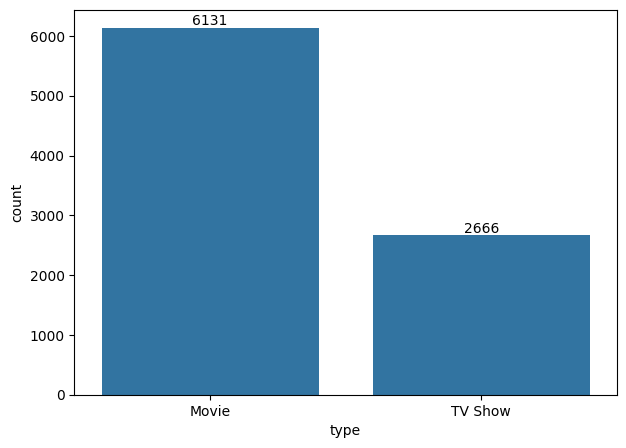

In [153]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x = df['type'])
ax.bar_label(ax.containers[0])
plt.show()

From total 8807 shows **6131** is **Movies** and **2666** is **TV SHow**



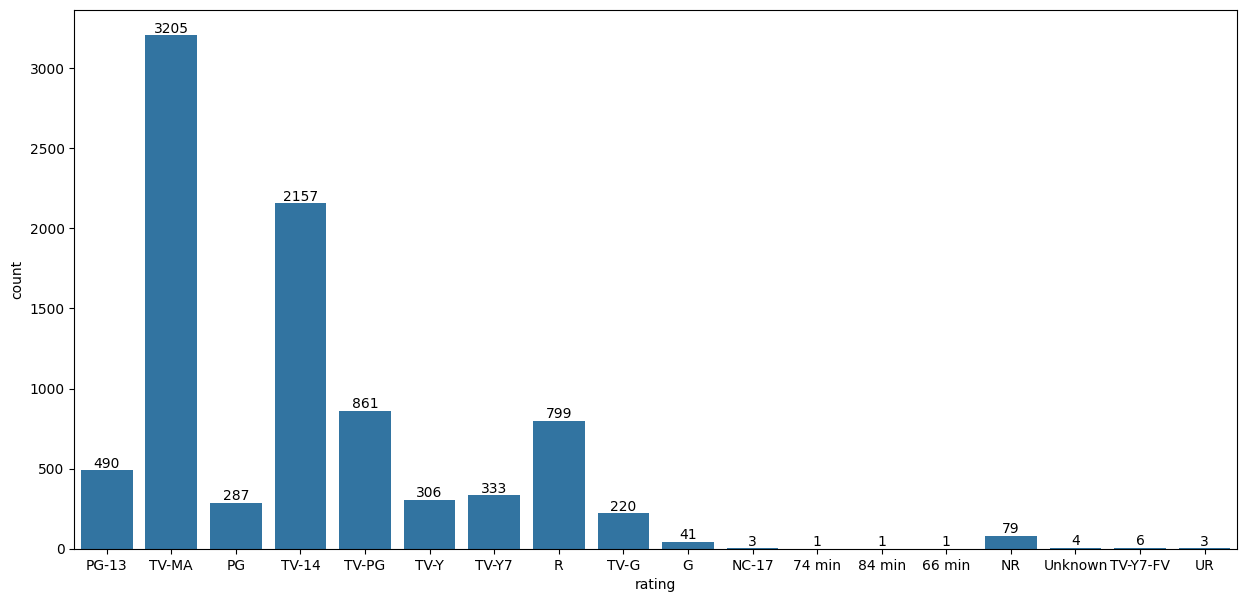

In [154]:
plt.figure(figsize=(15,7))
ax = sns.countplot(x = df['rating'])
ax.bar_label(ax.containers[0])
plt.show()

Netflix's catalog is heavily dominated by mature content, with TV-MA and TV-14 accounting for the majority of titles. This suggests that the platform primarily targets adult and teenage audiences rather than young children.

Data Cleaning Observation: The values "74 min", "84 min", and "66 min" appearing in the rating column are incorrect and likely belong to the duration column. These records should be corrected or handled during data preprocessing.

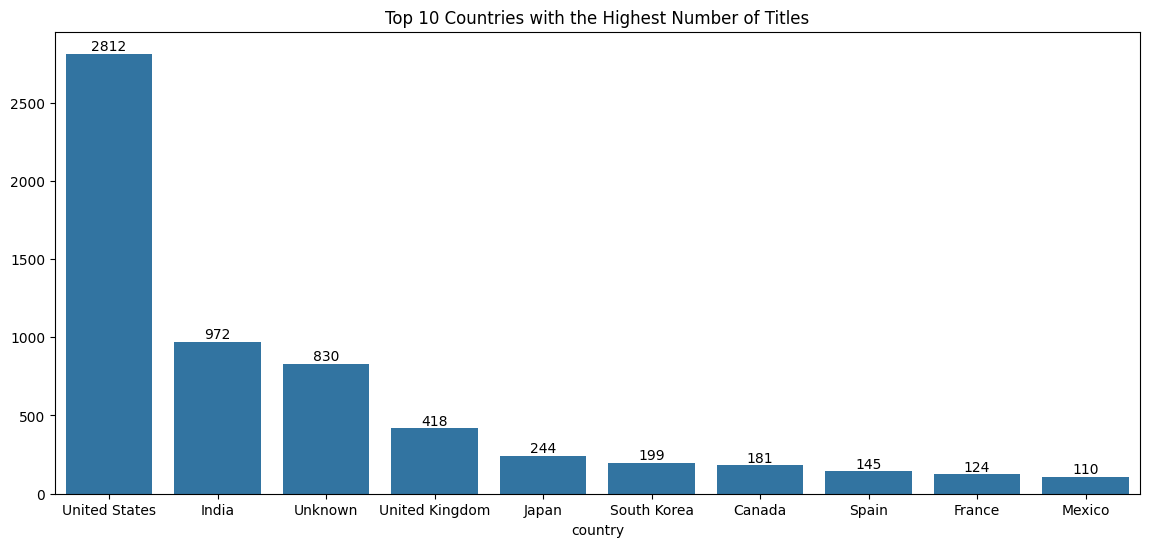

In [155]:
top_10 = df['country'].value_counts().head(10)
plt.figure(figsize=(14,6))
ax = sns.barplot(x = top_10.index,y = top_10.values)
ax.bar_label(ax.containers[0])
plt.title('Top 10 Countries with the Highest Number of Titles')
plt.show()

The Netflix catalog is heavily dominated by content produced in the United States, followed by India. The presence of a large number of 'Unknown' entries also indicates missing country information that should be considered during data cleaning and interpretation.

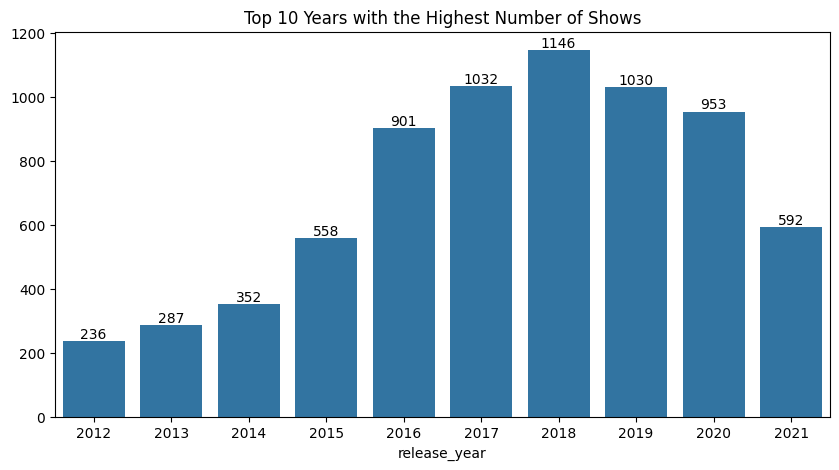

In [156]:
top_10 = df['release_year'].value_counts().head(10)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = top_10.index,y= top_10.values)
ax.bar_label(ax.containers[0])
plt.title('Top 10 Years with the Highest Number of Shows')
plt.show()

Netflix experienced rapid growth in content additions between 2012 and 2018, reaching its highest point in 2018. After this peak, the number of new titles gradually declined, although the platform continued to add a substantial amount of content.

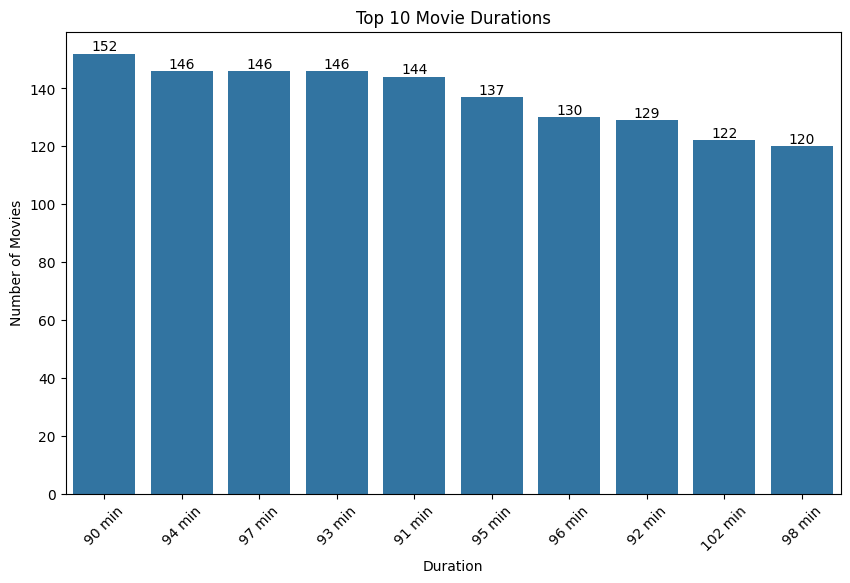

In [157]:
movies = df[df['type'] == 'Movie']

top_duration = movies['duration'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_duration.index, y=top_duration.values)

ax.bar_label(ax.containers[0])
plt.title("Top 10 Movie Durations")
plt.xlabel("Duration")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

Most movies on Netflix have a runtime between 90 and 100 minutes, with 90-minute films being the most common. This suggests that feature-length movies of around one and a half hours are the preferred format on the platform.

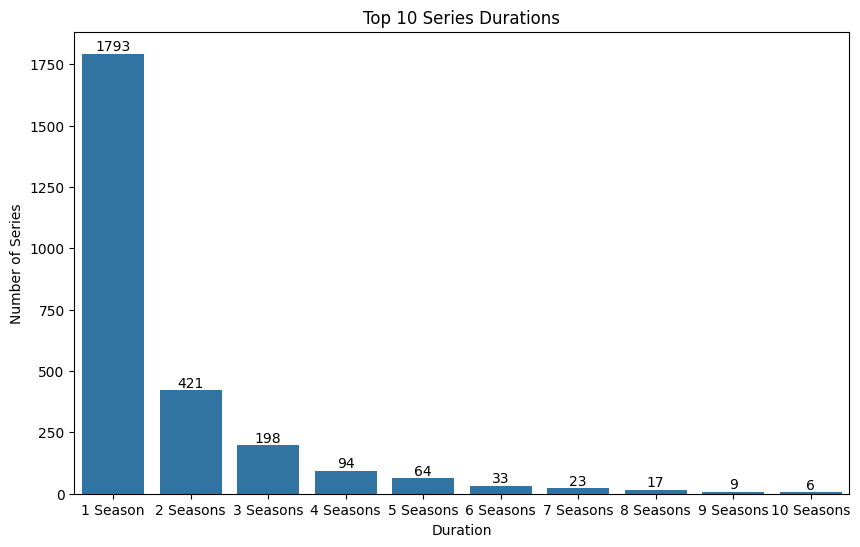

In [158]:
series = df[df['type'] == 'TV Show']

top_10 = series['duration'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_10.index,y=top_10.values)

ax.bar_label(ax.containers[0])
plt.title("Top 10 Series Durations")
plt.xlabel("Duration")
plt.ylabel("Number of Series")
plt.show()

Netflix's TV show catalog is heavily concentrated on short series, with the majority consisting of just one season. Long-running series with multiple seasons are comparatively rare.

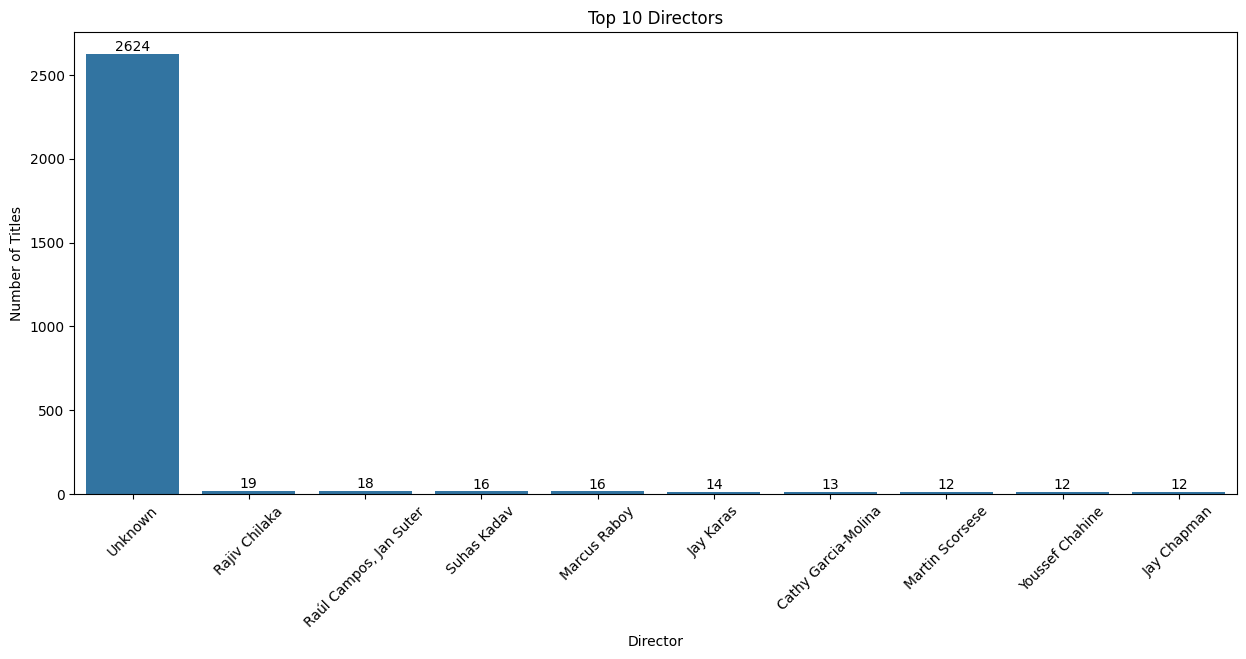

In [159]:
top_10 = df['director'].value_counts().head(10)
plt.figure(figsize=(15,6))
ax = sns.barplot(x= top_10.index,y=top_10.values)
ax.bar_label(ax.containers[0])

plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

A significant amount of director information is missing, as 'Unknown' accounts for the majority of records. Among the identified directors, Rajiv Chilaka has the highest number of titles in the dataset, although the difference between the top directors is relatively small.

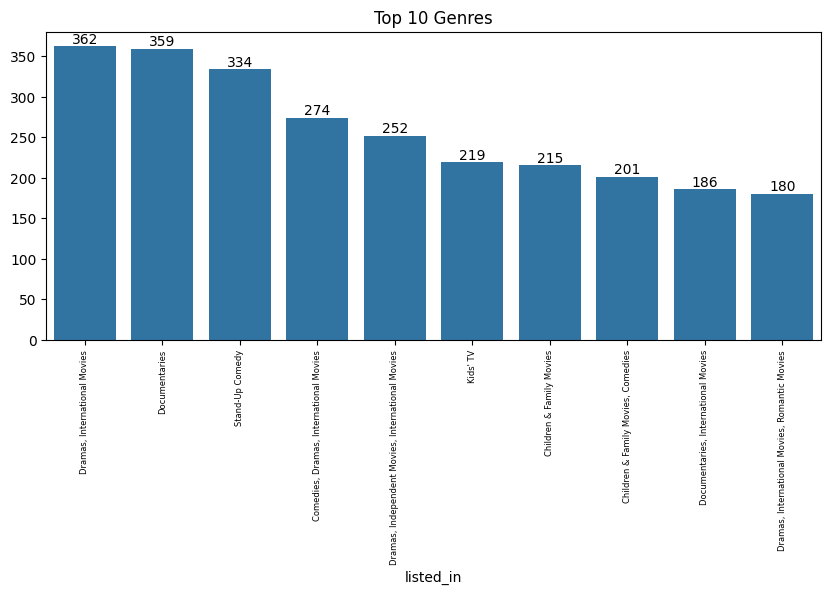

In [160]:
top_10 = df['listed_in'].value_counts().head(10)
plt.figure(figsize=(10,4))
ax = sns.barplot(x = top_10.index,y = top_10.values)
ax.bar_label(ax.containers[0])
plt.title('Top 10 Genres')
plt.xticks(fontsize = 6,rotation=90)
plt.show()

Netflix's library is dominated by international drama content, documentaries, and stand-up comedy. The frequent appearance of "International Movies" across multiple top genres suggests that Netflix places a strong emphasis on offering diverse content from around the world, while also maintaining a broad selection of documentaries and family-friendly programming.

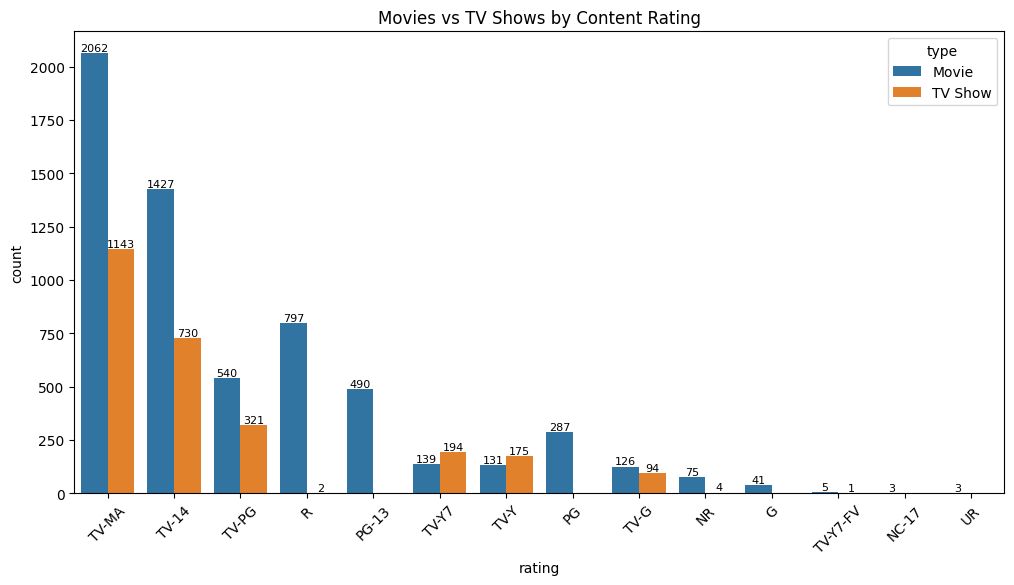

In [161]:
invalid = ['74 min','84 min','66 min','Unknown']

filtered_df = df[~df['rating'].isin(invalid)]

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=filtered_df,
    x='rating',
    hue='type',
    order=filtered_df['rating'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.xticks(rotation=45)
plt.title("Movies vs TV Shows by Content Rating")
plt.show()

Netflix's content is largely aimed at mature audiences, with TV-MA and TV-14 dominating both Movies and TV Shows. Movies feature more theatrical ratings such as R and PG-13, whereas TV Shows are primarily classified using television-specific ratings like TV-MA, TV-14, TV-PG, TV-Y, and TV-Y7.

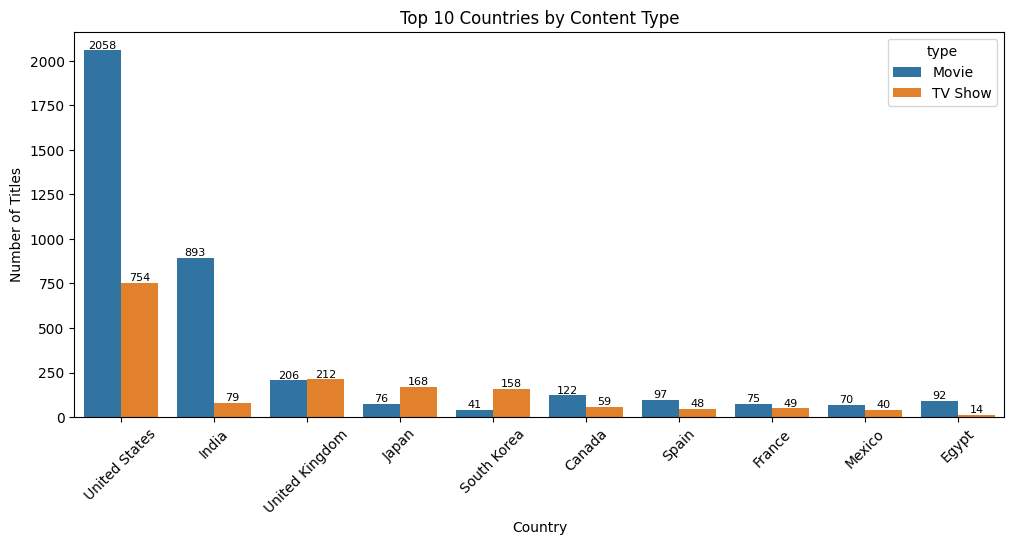

In [162]:
invalid = ['Unknown']

filtered_df = df[~df['country'].isin(invalid)]

plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=filtered_df,
    x='country',
    hue='type',
    order=filtered_df['country'].value_counts().head(10).index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.xticks(rotation=45)
plt.title("Top 10 Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

The United States is the leading producer of both Movies and TV Shows on Netflix, while India's contribution is primarily movie-focused. In contrast, countries such as Japan, South Korea, and the United Kingdom contribute relatively more TV Shows, highlighting regional differences in content production.

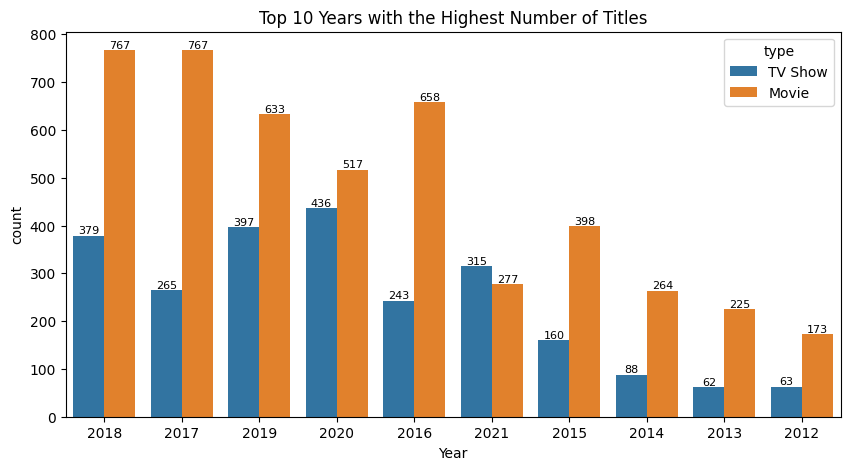

In [163]:
top_10 = df['release_year'].value_counts().head(10)
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='release_year',
    hue='type',
    order=top_10.index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Top 10 Years with the Highest Number of Titles")
plt.xlabel("Year")
plt.show()

Movies consistently outnumbered TV Shows across all years, with movie additions peaking in 2017 and 2018. In contrast, TV Show releases reached their highest point in 2020, indicating a shift toward increased investment in series content during that period.

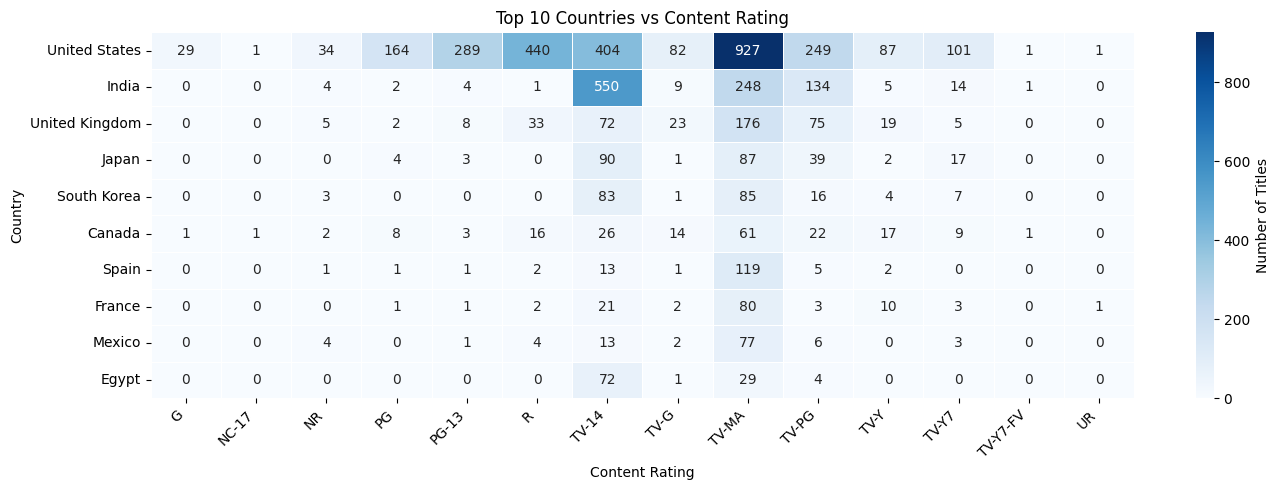

In [164]:
invalid = ['66 min', '74 min', '84 min', 'Unknown']

filtered_df = df[
    ~df['country'].isin(['Unknown']) &
    ~df['rating'].isin(invalid)
]

pivot = pd.crosstab(filtered_df['country'], filtered_df['rating'])

pivot = pivot.loc[
    filtered_df['country'].value_counts().head(10).index
]

plt.figure(figsize=(14, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Titles'}
)

plt.title("Top 10 Countries vs Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Country")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


Across almost all countries, Netflix's catalog is dominated by mature content (TV-MA and TV-14). The United States contributes the largest and most diverse collection of both Movies and TV Shows, while India's catalog is primarily movie-focused. Countries such as Japan and South Korea have a relatively stronger presence of TV Shows, but mature-rated content remains the dominant category worldwide.

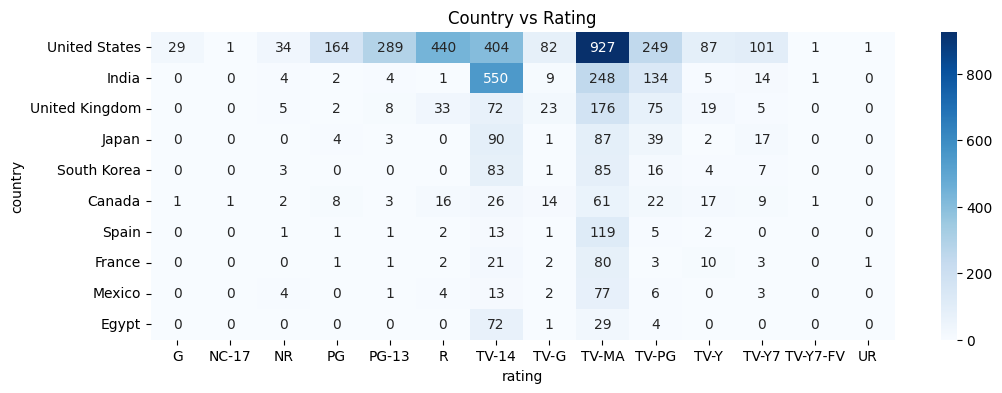

In [165]:
pivot = pd.crosstab(filtered_df['country'], filtered_df['rating'])

pivot = pivot.loc[
    filtered_df['country'].value_counts().head(10).index
]

plt.figure(figsize=(12,4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Country vs Rating")
plt.show()

TV-MA and TV-14 are the dominant content ratings across nearly all major content-producing countries, indicating that Netflix's catalog is primarily aimed at mature and teenage audiences. The United States leads in both the volume and diversity of content ratings, while other countries tend to concentrate on a smaller range of rating categories.

# Key Findings
1. Content Type Distribution
Movies account for approximately 70% of Netflix's catalog, while TV Shows represent around 30%.
This indicates that Netflix's library is primarily movie-focused.
2. Top Content-Producing Countries
The United States contributes the highest number of titles, followed by India and the United Kingdom.
The United States dominates both Movies and TV Shows, whereas India primarily contributes Movies.
Countries such as Japan, South Korea, and the United Kingdom have a relatively higher proportion of TV Shows.
3. Content Ratings
TV-MA is the most common rating, followed by TV-14 and TV-PG.
The majority of Netflix's content is intended for mature and teenage audiences.
Family-friendly ratings such as TV-Y, TV-Y7, and TV-G represent a smaller share of the catalog.
4. Popular Genres
The most common genres include:
Dramas, International Movies
Documentaries
Stand-Up Comedy
Comedies, Dramas, International Movies
Dramas, Independent Movies, International Movies
International content appears frequently across the top genres, highlighting Netflix's global content strategy.
5. Content Growth Over Time
Netflix experienced rapid content growth between 2012 and 2018.
The highest number of titles was added in 2018.
Although additions declined slightly after 2018, Netflix continued expanding its content library through 2020.
6. Movies vs TV Shows by Release Year
Movie releases peaked in 2017 and 2018.
TV Show releases reached their highest level in 2020, indicating increased investment in series during recent years.
7. Movie Duration
Most movies have runtimes between 90 and 100 minutes.
90-minute movies are the most common, suggesting Netflix favors standard feature-length films.
8. TV Show Duration
Most TV Shows consist of one season.
The number of titles decreases significantly as the number of seasons increases.
Long-running series are relatively uncommon.
9. Directors
Rajiv Chilaka has the highest number of titles among known directors.
A large number of records initially contained missing director information, which was handled during data cleaning.
10. Country vs Rating
TV-MA and TV-14 dominate across almost every major content-producing country.
The United States has the widest variety of content ratings.
Mature-rated content is the primary focus across Netflix's global catalog.
11. Data Cleaning Observations
Missing values in columns such as country, director, cast, and rating were handled appropriately.
Incorrect rating values such as "66 min", "74 min", and "84 min" were identified as data quality issues and excluded from rating-based analysis.
"Unknown" values were removed where necessary to improve the accuracy of visualizations.

# Conclusion

This Exploratory Data Analysis (EDA) provides valuable insights into Netflix's content library by examining content types, ratings, genres, release trends, durations, countries, and directors. The analysis reveals that Movies make up the majority of Netflix's catalog, while TV-MA and TV-14 are the most common content ratings, indicating that the platform primarily targets mature and teenage audiences.

The United States is the leading contributor of Netflix content, followed by India and the United Kingdom, while countries such as Japan and South Korea contribute a comparatively higher proportion of TV Shows. Netflix also demonstrates a strong emphasis on international content, as evidenced by the popularity of genres containing International Movies.

The platform experienced significant growth between 2012 and 2018, reaching its peak in 2018, before stabilizing in subsequent years. Most movies have runtimes of approximately 90–100 minutes, whereas the majority of TV Shows consist of only one season, indicating a preference for shorter series.

Overall, this analysis highlights Netflix's strategy of maintaining a diverse, globally distributed content library with a strong focus on mature audiences, international programming, documentaries, and feature-length films. The data cleaning process also emphasized the importance of handling missing values and correcting data quality issues to ensure reliable analysis and meaningful insights.

# Future Work

Perform sentiment analysis using movie descriptions.

Analyze the relationship between genres and content ratings.

Build a recommendation system based on genres, cast, and directors.

Predict content ratings or popularity using machine learning techniques.

Create an interactive dashboard in Power BI or Tableau for deeper exploration.